# Results — a free λ sweep from one FLUX.1-dev SMC run

**Source run:** Slurm job `693836`, node `n-803` (NVIDIA L40S, 45 GB), 2026-07-30 02:39 → 04:49.
Completed naturally in **111.3 min** of a 420 min allocation — β reached 1.0, so this is *not* a timeout.

This notebook is read-only analysis: it loads `levels_N8_lam168_seed101.pt` and reports everything the run
recorded, then decodes every level's latents back to images through FLUX.1-dev's own VAE. It re-derives
nothing — no sampler is run here, so it is cheap to re-execute and safe to re-render with different layouts.

**The claim being tested.** Adaptive tempering walks β from 0 to 1, and level *k* holds a cloud targeting

$$\pi_{\beta_{k}} \propto p(x) \exp(\beta_{k} \lambda_{\max} f(x)) = q_{\lambda_{\text{eff}}},
\qquad \lambda_{\text{eff}} = \beta_{k} \cdot \lambda_{\max}$$

so a *single* run at $\lambda_{\max}$ already contains a whole λ sweep, at **identical** reward, references,
Brownian seed and base density — a comparability that separate per-λ runs can never quite claim.

**Read the caveats in the Takeaways cell before quoting any row as a sample from $q_{\lambda}$.**

In [1]:
import math
import os

import matplotlib.pyplot as plt
import torch

CKPT = "levels_N8_lam168_seed101.pt"          # final checkpoint (has true `ancestors`)
PARTIAL = "partial_N8_seed101.pt"             # per-sweep checkpoint (arange ancestors, carries z)

d = torch.load(CKPT, map_location="cpu", weights_only=False)
cfg, levels = d["config"], d["levels"]
N = cfg["N"]
C, H, W = cfg["C"], cfg["H"], cfg["W"]

print(f"checkpoint : {CKPT}  ({os.path.getsize(CKPT) / 2**20:.1f} MB)")
print(f"partial    : {PARTIAL}  ({os.path.getsize(PARTIAL) / 2**20:.1f} MB)"
      if os.path.exists(PARTIAL) else "partial    : (absent)")
print(f"completed  : partial={d['partial']}  timed_out={cfg.get('timed_out')}  "
      f"wall={cfg['wall_clock_min']:.1f} min")

print("\n--- model / prompt ---")
print(f"  model      : {cfg['model_id']}")
print(f"  prompt     : {cfg['prompt']!r}   guidance = {cfg['guidance']}")
print(f"  latents    : {cfg['img']}x{cfg['img']} px -> ({C}, {H}, {W}) = d {cfg['latent_dim']}")
print(f"  VAE        : scaling={cfg['vae_scaling_factor']}  shift={cfg['vae_shift_factor']}")
print(f"  G          : EDM Heun, n_steps={cfg['n_steps']}, "
      f"sigma in [{cfg['sigma_min']}, {cfg['sigma_max']}]")

print("\n--- reward (IEM) ---")
print(f"  R (refs)   : {cfg['R']}")
print(f"  N_GAMMA    : {cfg['n_gamma']}   (gamma-integration nodes)")
print(f"  NUM_EPS    : {cfg['num_eps']}   (Brownian paths; inner score batch = NUM_EPS*N)")

print("\n--- sampler ---")
print(f"  N          : {N} particles")
print(f"  ess_target : {cfg['ess_target']}")
print(f"  n_mcmc     : {cfg['n_mcmc']} (adaptive)   max_n_mcmc = {cfg['max_n_mcmc']}")
print(f"  seed       : {cfg['seed']}")

print("\n--- lambda calibration ---")
print(f"  lambda_s   : {cfg['lam_s']:.2f}   (= 1/std_p(f), from 8 probe samples: +-27%)")
print(f"  LAM_MAX    : {cfg['lam_max']:.2f}   (= 3 * lambda_s, the m=3 bracketing rule)")

print("\n--- measured cost ---")
print(f"  per pass   : {cfg['t_per_pass_s'] * 1000:.0f} ms  (one single-image transformer pass)")
print(f"  normalizer : {cfg['t_norm_s'] / 60:.2f} min  (the R x R E_pair[D^2] term, paid once)")
print(f"  per sweep  : {cfg['t_sweep_s'] / 60:.2f} min  (one G call + one reward call)")
print(f"  per level  : {cfg['t_sweep_s'] * cfg['max_n_mcmc'] / 3600:.2f} h  at the sweep cap")

checkpoint : levels_N8_lam168_seed101.pt  (14.0 MB)
partial    : partial_N8_seed101.pt  (24.0 MB)
completed  : partial=False  timed_out=False  wall=111.3 min

--- model / prompt ---
  model      : black-forest-labs/FLUX.1-dev
  prompt     : 'A dog'   guidance = 3.5
  latents    : 512x512 px -> (16, 64, 64) = d 65536
  VAE        : scaling=0.3611  shift=0.1159
  G          : EDM Heun, n_steps=8, sigma in [0.002, 80.0]

--- reward (IEM) ---
  R (refs)   : 4
  N_GAMMA    : 6   (gamma-integration nodes)
  NUM_EPS    : 3   (Brownian paths; inner score batch = NUM_EPS*N)

--- sampler ---
  N          : 8 particles
  ess_target : 0.85
  n_mcmc     : None (adaptive)   max_n_mcmc = 16
  seed       : 101

--- lambda calibration ---
  lambda_s   : 55.88   (= 1/std_p(f), from 8 probe samples: +-27%)
  LAM_MAX    : 167.64   (= 3 * lambda_s, the m=3 bracketing rule)

--- measured cost ---
  per pass   : 161 ms  (one single-image transformer pass)
  normalizer : 0.87 min  (the R x R E_pair[D^2] term,

## 1. The β schedule, rejuvenation effort, and why each level stopped

`len(levels) == len(betas) + 1` — `levels[0]` is the free β=0, λ_eff=0 anchor (plain samples from $p$), so
level *k* ≥ 1 carries `betas[k-1]`.

Columns, and what each is good for:

| column | meaning |
|---|---|
| `E_q[f]` | mean reward at that level — the novelty actually achieved |
| `ESS/N` | effective sample size **as a fraction** (`ess_history` stores raw counts in [1, N]) |
| `acc` | pCN Metropolis acceptance during rejuvenation; the adapter targets 0.23 |
| `uniq/N` | distinct particle rows *within* the level (`X.unique(dim=0)`) |
| `f-std` | within-ensemble spread of $f$ — catches collapse that `uniq/N` misses |
| `sweeps` | `n_mcmc_history`: adaptive rejuvenation length, in [4, `max_n_mcmc`] |
| `stop` | `decorr` = the decorrelation rule fired; `cap` = it never did |

The `stop` column is the interesting one: it answers empirically whether pCN's 2D-calibrated
`decorr_threshold = 0.2` transfers to $d = 65536$.

In [2]:
# Raw histories exactly as the run recorded them.
print(f"betas               = {[round(b, 4) for b in d['betas']]}")
print(f"ess_history (raw)   = {[round(float(e), 2) for e in d['ess_history']]}   (out of N={N})")
print(f"acc_history         = {[round(float(a), 3) for a in d['acc_history']]}")
print(f"n_mcmc_history      = {d['n_mcmc_history']}   (total {sum(d['n_mcmc_history'])} sweeps)")
print(f"stop_reason_history = {d['stop_reason_history']}")

# Per-level table. ess/acc are per TRANSITION (len == len(betas)), so level 0 has none.
lam_eff = [l["lam_eff"] for l in levels]
Eqf = [float(l["fX"].mean()) for l in levels]
f_std = [float(l["fX"].std()) for l in levels]
uniq = [int(l["X"].unique(dim=0).shape[0]) / N for l in levels]
ess = [float("nan")] + [float(e) / N for e in d["ess_history"]]
acc = [float("nan")] + [float(a) for a in d["acc_history"]]
sweeps = [0] + list(d["n_mcmc_history"])
stops = ["-"] + list(d["stop_reason_history"])
base_f = Eqf[0]

print(f"\n{'k':>2} {'beta':>7} {'lam_eff':>8} {'m':>5} {'E_q[f]':>8} {'d f':>8} "
      f"{'ESS/N':>6} {'acc':>6} {'uniq/N':>7} {'f-std':>8} {'sweeps':>7} {'stop':>7}")
for k, l in enumerate(levels):
    print(f"{k:2d} {l['beta']:7.4f} {lam_eff[k]:8.1f} {lam_eff[k] / cfg['lam_s']:5.2f} "
          f"{Eqf[k]:8.4f} {Eqf[k] - base_f:+8.4f} {ess[k]:6.2f} {acc[k]:6.2f} "
          f"{uniq[k]:7.2f} {f_std[k]:8.4f} {sweeps[k]:7d} {stops[k]:>7}")

n_cap = sum(1 for r in d["stop_reason_history"] if r == "cap")
n_tot = len(d["stop_reason_history"])
print(f"\nlevels that hit the sweep cap: {n_cap}/{n_tot}")
if n_cap:
    capped_at = [round(b, 3) for b, r in zip(d["betas"], d["stop_reason_history"]) if r == "cap"]
    print(f"  cap was binding at beta = {capped_at}")
    print(f"  -> at those levels {cfg['max_n_mcmc']} sweeps did NOT decorrelate the cloud, so the")
    print(f"     2D-calibrated decorr_threshold=0.2 does NOT transfer to d={cfg['latent_dim']}.")
    print(f"     Mixing, not reward fidelity, is the binding constraint there.")
else:
    print("  -> 'decorr' fired everywhere; the cap was never binding.")

print(f"\nnovelty gain over the whole sweep: E_q[f] {base_f:.4f} -> {Eqf[-1]:.4f} "
      f"({100 * (Eqf[-1] / base_f - 1):+.1f}%)")
print("monotone in lambda_eff:",
      all(Eqf[k] <= Eqf[k + 1] + 1e-9 for k in range(len(Eqf) - 1)))

betas               = [0.1419, 0.268, 0.4637, 0.77, 1.0]
ess_history (raw)   = [6.8, 6.8, 6.8, 6.8, 7.07]   (out of N=8)
acc_history         = [0.802, 0.562, 0.354, 0.133, 0.172]
n_mcmc_history      = [12, 6, 6, 16, 16]   (total 56 sweeps)
stop_reason_history = ['decorr', 'decorr', 'decorr', 'cap', 'cap']



 k    beta  lam_eff     m   E_q[f]      d f  ESS/N    acc  uniq/N    f-std  sweeps    stop
 0  0.0000      0.0  0.00   1.0055  +0.0000    nan    nan    1.00   0.0203       0       -
 1  0.1419     23.8  0.43   1.0052  -0.0003   0.85   0.80    1.00   0.0208      12  decorr
 2  0.2680     44.9  0.80   1.0161  +0.0106   0.85   0.56    1.00   0.0139       6  decorr
 3  0.4637     77.7  1.39   1.0284  +0.0229   0.85   0.35    1.00   0.0102       6  decorr
 4  0.7700    129.1  2.31   1.0403  +0.0347   0.85   0.13    1.00   0.0106      16     cap
 5  1.0000    167.6  3.00   1.0488  +0.0433   0.88   0.17    1.00   0.0166      16     cap

levels that hit the sweep cap: 2/5
  cap was binding at beta = [0.77, 1.0]
  -> at those levels 16 sweeps did NOT decorrelate the cloud, so the
     2D-calibrated decorr_threshold=0.2 does NOT transfer to d=65536.
     Mixing, not reward fidelity, is the binding constraint there.

novelty gain over the whole sweep: E_q[f] 1.0055 -> 1.0488 (+4.3%)
monotone in 

## 2. Diagnostics

Four panels, all from data already in the checkpoint — no reward calls.

The selection rule recorded in CLAUDE.md: $E_{q}[f]$ rises forever with λ, so **novelty is not the stopping
signal — degeneracy is**. Take the largest λ whose ensemble diversity stays above ~0.5.

Read `uniq/N` sceptically here. pCN rejuvenation nudges duplicated particles apart, so an ensemble that has
effectively collapsed can still present as N distinct rows. **Acceptance** and **f-std** are the corroborating
signals, which is why they get their own panels.

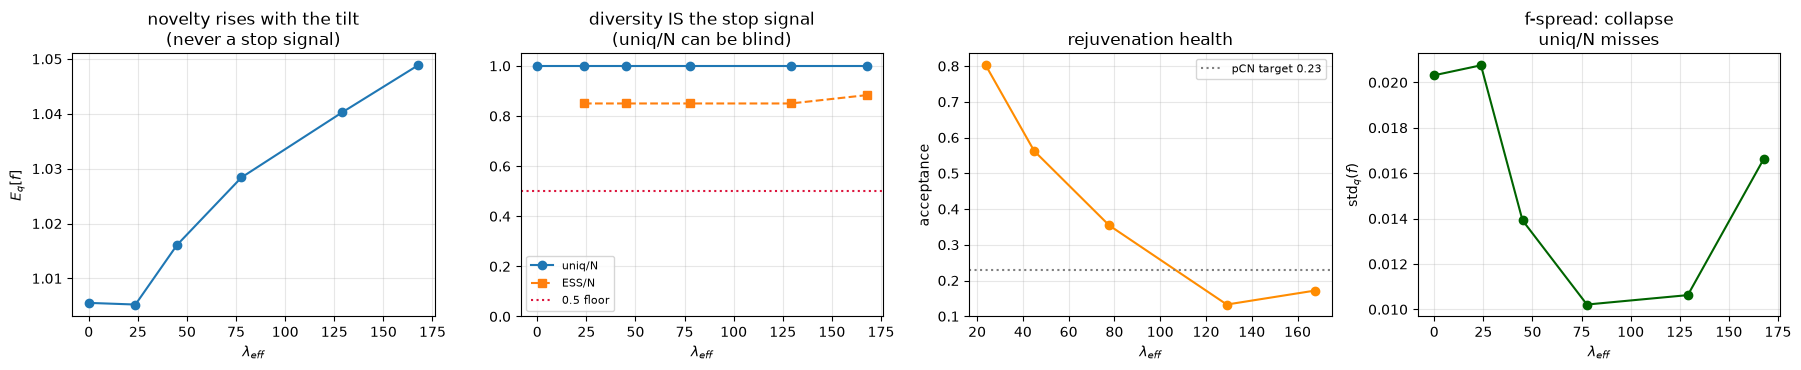

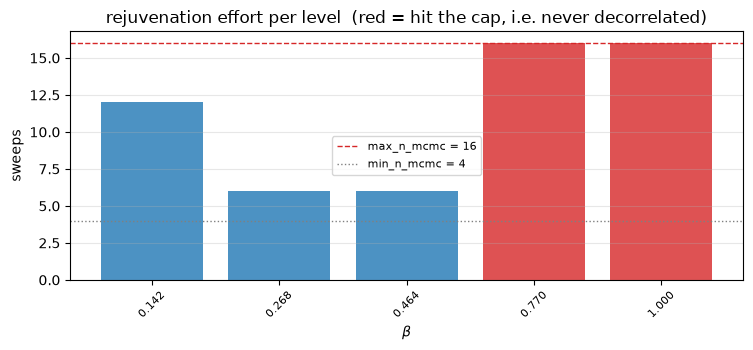

selector (uniq/N and ESS/N >= 0.5) -> level 5, lambda_eff = 167.6

CAUTION: uniq/N == 1.00 at EVERY level, so the diversity floor never binds and the
selector degenerates to 'pick the last level'. The signals that do move:
    level 0: acc=nan  f-std=0.0203
    level 1: acc=0.80  f-std=0.0208
    level 2: acc=0.56  f-std=0.0139
    level 3: acc=0.35  f-std=0.0102
    level 4: acc=0.13  f-std=0.0106
    level 5: acc=0.17  f-std=0.0166
  acceptance bottoms out at level 4 (acc=0.13), and f-std falls 0.0203 -> 0.0102.
  Judge the working point from the images below, not from this selector.


In [3]:
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))

ax[0].plot(lam_eff, Eqf, "o-")
ax[0].set_xlabel(r"$\lambda_{eff}$"); ax[0].set_ylabel(r"$E_q[f]$")
ax[0].set_title("novelty rises with the tilt\n(never a stop signal)")

ax[1].plot(lam_eff, uniq, "o-", label="uniq/N")
ax[1].plot(lam_eff, ess, "s--", label="ESS/N")
ax[1].axhline(0.5, color="crimson", ls=":", label="0.5 floor")
ax[1].set_ylim(0, 1.05); ax[1].set_xlabel(r"$\lambda_{eff}$")
ax[1].legend(fontsize=8); ax[1].set_title("diversity IS the stop signal\n(uniq/N can be blind)")

ax[2].plot(lam_eff, acc, "o-", color="darkorange")
ax[2].axhline(0.23, color="grey", ls=":", label="pCN target 0.23")
ax[2].set_xlabel(r"$\lambda_{eff}$"); ax[2].set_ylabel("acceptance")
ax[2].legend(fontsize=8); ax[2].set_title("rejuvenation health")

ax[3].plot(lam_eff, f_std, "o-", color="darkgreen")
ax[3].set_xlabel(r"$\lambda_{eff}$"); ax[3].set_ylabel(r"std$_q(f)$")
ax[3].set_title("f-spread: collapse\nuniq/N misses")
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Rejuvenation effort per level, annotated with why each level stopped.
fig, ax = plt.subplots(figsize=(7.5, 3.6))
xs = range(len(d["betas"]))
colors = ["tab:red" if r == "cap" else "tab:blue" for r in d["stop_reason_history"]]
ax.bar(xs, d["n_mcmc_history"], color=colors, alpha=0.8)
ax.axhline(cfg["max_n_mcmc"], ls="--", color="tab:red", lw=1,
           label=f"max_n_mcmc = {cfg['max_n_mcmc']}")
ax.axhline(4, ls=":", color="grey", lw=1, label="min_n_mcmc = 4")
ax.set_xticks(list(xs))
ax.set_xticklabels([f"{b:.3f}" for b in d["betas"]], rotation=45, fontsize=8)
ax.set_xlabel(r"$\beta$"); ax.set_ylabel("sweeps")
ax.set_title("rejuvenation effort per level  (red = hit the cap, i.e. never decorrelated)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

# Apply the established selector, then state where it is untrustworthy.
ok = [k for k in range(len(levels))
      if uniq[k] >= 0.5 and (math.isnan(ess[k]) or ess[k] >= 0.5)]
best = max(ok) if ok else None
print(f"selector (uniq/N and ESS/N >= 0.5) -> level {best}, lambda_eff = {lam_eff[best]:.1f}"
      if best is not None else "selector: no level clears the 0.5 floor")
if best is not None and all(u == 1.0 for u in uniq):
    print("\nCAUTION: uniq/N == 1.00 at EVERY level, so the diversity floor never binds and the")
    print("selector degenerates to 'pick the last level'. The signals that do move:")
    for k in range(len(levels)):
        print(f"    level {k}: acc={acc[k]:.2f}  f-std={f_std[k]:.4f}")
    worst = min(range(1, len(levels)), key=lambda k: acc[k])
    print(f"  acceptance bottoms out at level {worst} (acc={acc[worst]:.2f}), and f-std falls "
          f"{f_std[0]:.4f} -> {min(f_std):.4f}.")
    print("  Judge the working point from the images below, not from this selector.")

## 3. The images — decoding the latents back through FLUX.1-dev's VAE

The saved `X` at each level are **FLUX latents in data space**, `(16, 64, 64)` flattened. Recovering images
needs only the `vae/` component of FLUX.1-dev — the same repo, ~168 MB — not the 24 GB transformer. So this
section is cheap and runs on a small GPU or on CPU.

Undoing the model's normalization is `latent / scaling_factor + shift_factor`, with both constants read from
the checkpoint rather than hardcoded, so a rerun with a different VAE stays correct.

**Row 0 is the go/no-go gate.** It is β=0, λ_eff=0 — the untilted cloud, i.e. plain prompt-conditional FLUX
samples. If those are not clean, on-prompt images, then the flow-matching → EDM adapter is wrong and every
number above is measuring the geometry of a broken score field.

In [4]:
from diffusers import AutoencoderKL
from diffusers.image_processor import VaeImageProcessor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# fp32 on CPU: a bf16 VAE decode on CPU is slow and numerically poor.
VDTYPE = torch.bfloat16 if DEVICE.type == "cuda" else torch.float32
print(f"decoding on {DEVICE} ({VDTYPE})")

vae = AutoencoderKL.from_pretrained(
    cfg["model_id"], subfolder="vae", torch_dtype=VDTYPE
).to(DEVICE).eval()
proc = VaeImageProcessor(vae_scale_factor=8)
SF, SHIFT = cfg["vae_scaling_factor"], cfg["vae_shift_factor"]


def decode(flat: torch.Tensor, chunk: int = 2) -> torch.Tensor:
    """Flat FLUX latents (B, 65536) -> images (B, 3, 512, 512) in [0, 1]."""
    outs = []
    for i in range(0, flat.shape[0], chunk):
        lat = flat[i : i + chunk].reshape(-1, C, H, W).to(DEVICE, VDTYPE)
        lat = lat / SF + SHIFT                       # undo the model's normalization
        with torch.no_grad():
            img = vae.decode(lat).sample
        outs.append(proc.postprocess(img.float(), output_type="pt").cpu())
    return torch.cat(outs)


# Column order by LINEAGE: walk `ancestors` backwards from the final level, so column j follows one
# particle's drift as the tilt strengthens. This checkpoint carries true ancestors (the partial file
# would not). Repeated images across a row mean COALESCENCE -- the resampler killed one lineage and
# duplicated another. Showing that is the point, not a defect.
col_of = [None] * len(levels)
cur = torch.arange(N)
col_of[-1] = cur
for k in range(len(levels) - 1, 0, -1):
    cur = levels[k]["ancestors"][cur]
    col_of[k - 1] = cur
lineage_uniq = [int(torch.unique(c).numel()) for c in col_of]
print(f"distinct final-level lineages present at each level: {lineage_uniq}")
print("(necessarily N at the last level -- that is a property of the backward walk, not diversity)")

decoded = []
for k, l in enumerate(levels):
    decoded.append(decode(l["X"][col_of[k]]))
    print(f"  level {k}  lam_eff={l['lam_eff']:7.1f}  decoded {tuple(decoded[-1].shape)}")

/home/dcor/arielzoizner/miniconda3/envs/creativity-measure/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


decoding on cuda (torch.bfloat16)


distinct final-level lineages present at each level: [6, 6, 6, 7, 8, 8]
(necessarily N at the last level -- that is a property of the backward walk, not diversity)


  level 0  lam_eff=    0.0  decoded (8, 3, 512, 512)


  level 1  lam_eff=   23.8  decoded (8, 3, 512, 512)


  level 2  lam_eff=   44.9  decoded (8, 3, 512, 512)


  level 3  lam_eff=   77.7  decoded (8, 3, 512, 512)


  level 4  lam_eff=  129.1  decoded (8, 3, 512, 512)


  level 5  lam_eff=  167.6  decoded (8, 3, 512, 512)


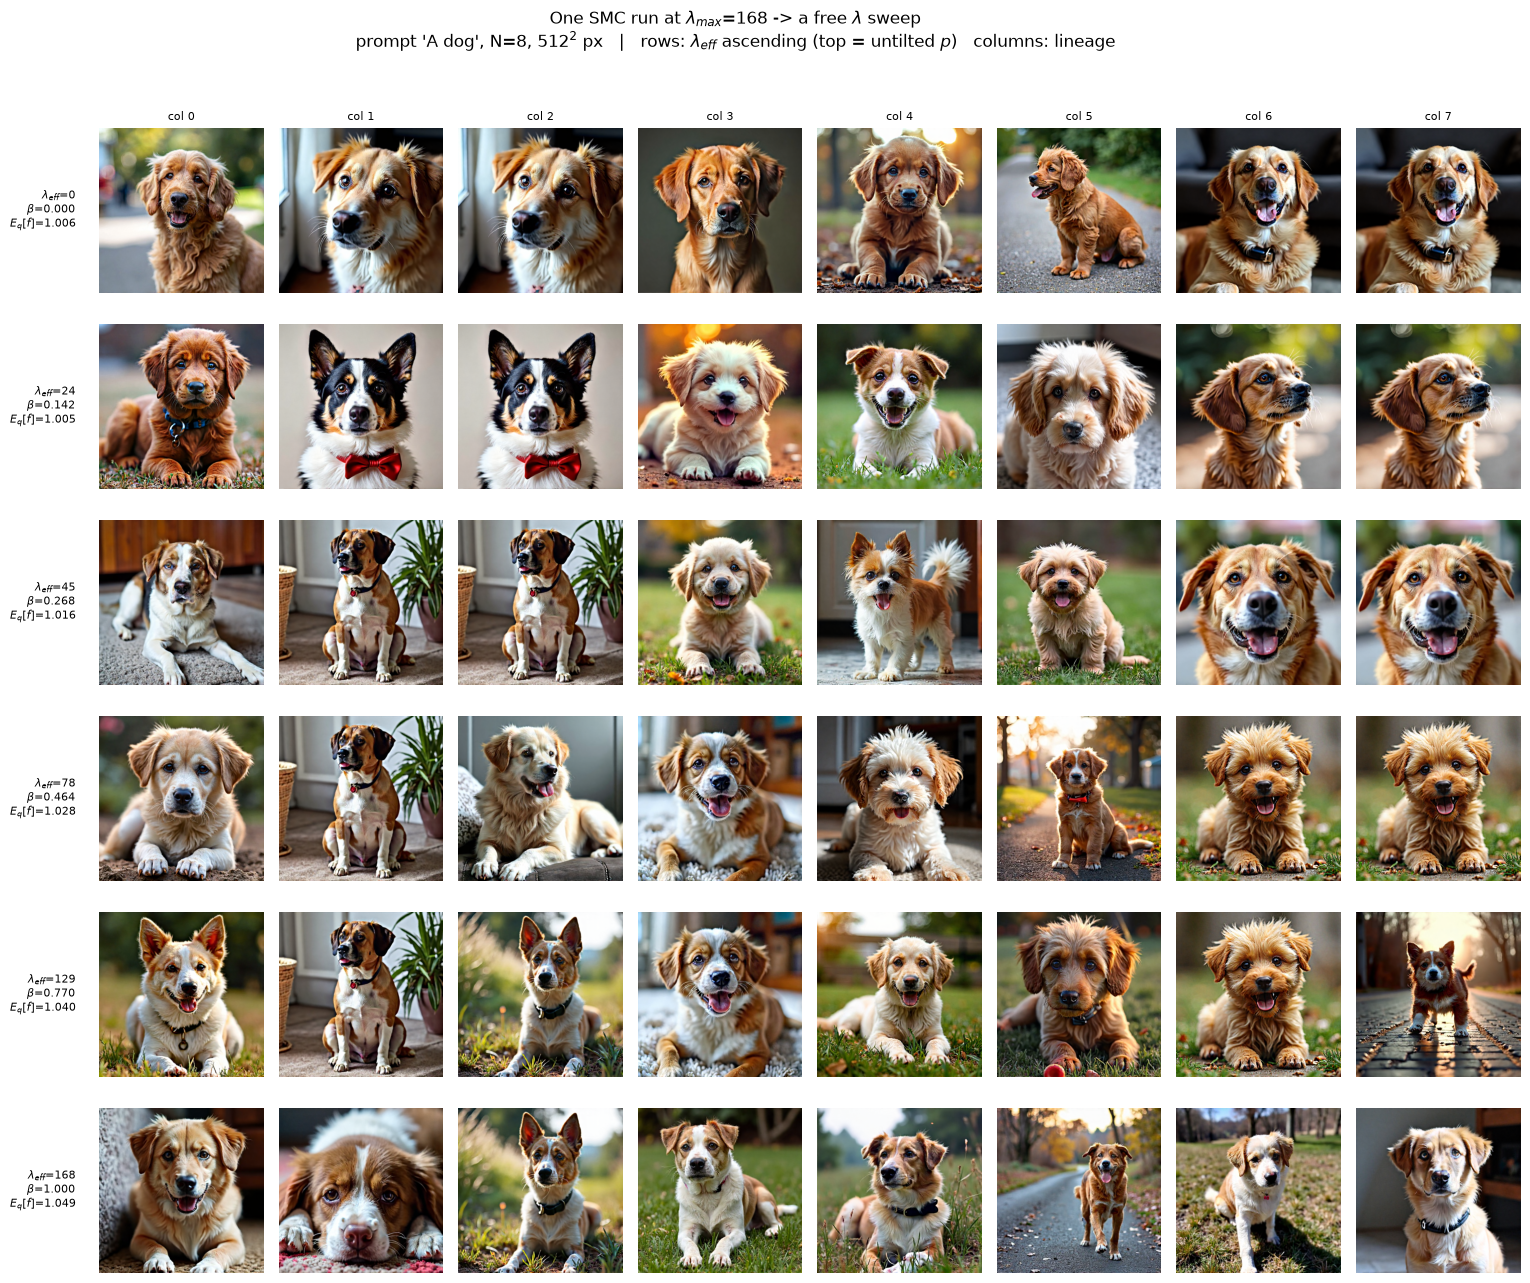

grid also written to lambda_sweep_grid.png (5.0 MB)


In [5]:
# The sweep grid: rows = lambda_eff ascending, columns = one particle's lineage.
nrow, ncol = len(levels), N
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 2.0, nrow * 2.2), squeeze=False)
for k in range(nrow):
    for j in range(ncol):
        a = axes[k][j]
        a.axis("off")
        a.imshow(decoded[k][j].permute(1, 2, 0).clamp(0, 1).numpy())
        if j == 0:
            a.text(-0.14, 0.5,
                   f"$\\lambda_{{eff}}$={lam_eff[k]:.0f}\n$\\beta$={levels[k]['beta']:.3f}\n"
                   f"$E_q[f]$={Eqf[k]:.3f}",
                   transform=a.transAxes, ha="right", va="center", fontsize=8)
        if k == 0:
            a.set_title(f"col {j}", fontsize=8)
fig.suptitle(
    f"One SMC run at $\\lambda_{{max}}$={cfg['lam_max']:.0f} -> a free $\\lambda$ sweep\n"
    f"prompt {cfg['prompt']!r}, N={N}, {cfg['img']}$^2$ px   |   "
    f"rows: $\\lambda_{{eff}}$ ascending (top = untilted $p$)   columns: lineage",
    fontsize=12,
)
plt.tight_layout(rect=(0.04, 0, 1, 0.965))
plt.show()

# Save a standalone PNG so the grid can be shared without opening the notebook.
fig.savefig("lambda_sweep_grid.png", dpi=140, bbox_inches="tight")
print(f"grid also written to lambda_sweep_grid.png "
      f"({os.path.getsize('lambda_sweep_grid.png') / 2**20:.1f} MB)")

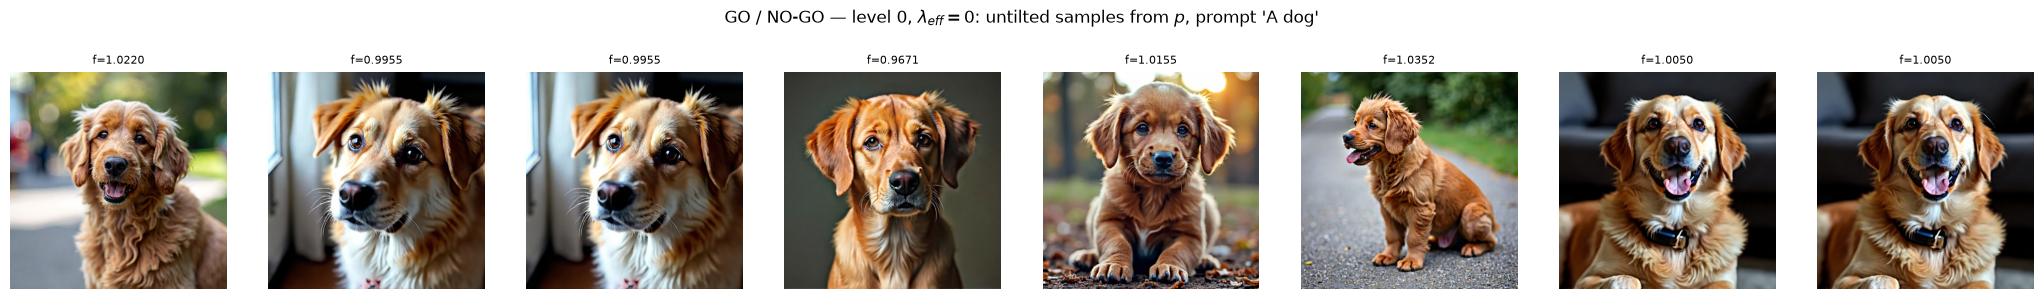

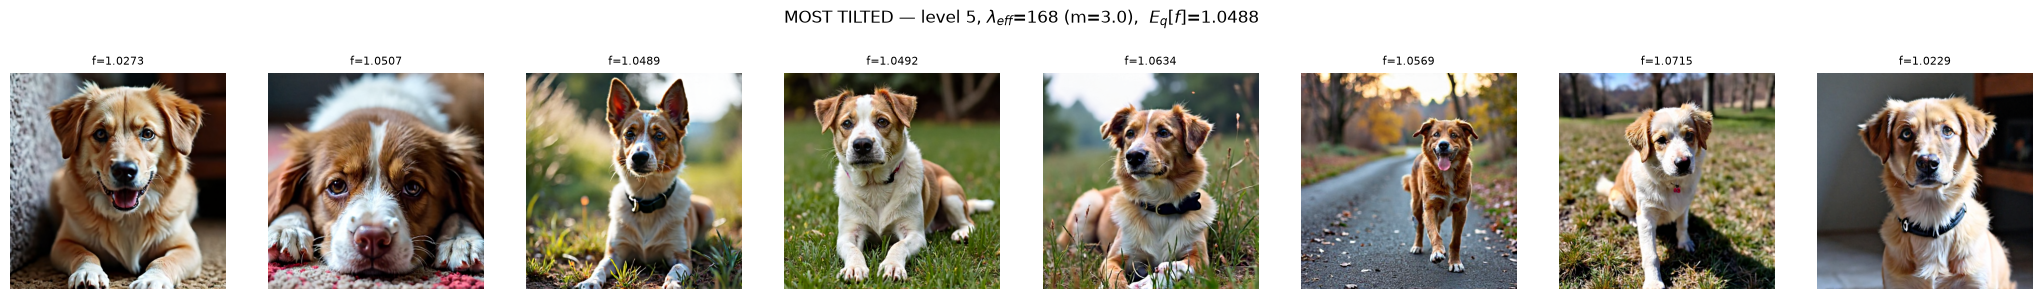

wrote 48 PNGs to decoded/  (naming: lvl<k>_lam<lambda_eff>_col<lineage column>.png)


In [6]:
# The gate, enlarged: the untilted anchor row (beta=0) is plain prompt-conditional FLUX.
# If these are not clean, on-prompt images, the velocity -> denoiser adapter is wrong.
fig, axes = plt.subplots(1, N, figsize=(N * 2.6, 3.0), squeeze=False)
for j in range(N):
    a = axes[0][j]
    a.axis("off")
    a.imshow(decoded[0][j].permute(1, 2, 0).clamp(0, 1).numpy())
    a.set_title(f"f={float(levels[0]['fX'][col_of[0][j]]):.4f}", fontsize=8)
fig.suptitle(f"GO / NO-GO — level 0, $\\lambda_{{eff}}=0$: untilted samples from $p$, "
             f"prompt {cfg['prompt']!r}", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

# The most-tilted row, enlarged, for comparison against the gate.
kmax = len(levels) - 1
fig, axes = plt.subplots(1, N, figsize=(N * 2.6, 3.0), squeeze=False)
for j in range(N):
    a = axes[0][j]
    a.axis("off")
    a.imshow(decoded[kmax][j].permute(1, 2, 0).clamp(0, 1).numpy())
    a.set_title(f"f={float(levels[kmax]['fX'][col_of[kmax][j]]):.4f}", fontsize=8)
fig.suptitle(f"MOST TILTED — level {kmax}, $\\lambda_{{eff}}$={lam_eff[kmax]:.0f} "
             f"(m={lam_eff[kmax] / cfg['lam_s']:.1f}),  $E_q[f]$={Eqf[kmax]:.4f}", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

# Per-level PNGs, so any single image can be inspected or shared at full resolution.
from PIL import Image

os.makedirs("decoded", exist_ok=True)
for k in range(len(levels)):
    for j in range(N):
        arr = (decoded[k][j].permute(1, 2, 0).clamp(0, 1) * 255).round().to(torch.uint8).numpy()
        Image.fromarray(arr).save(f"decoded/lvl{k:02d}_lam{lam_eff[k]:.0f}_col{j}.png")
n_png = len(os.listdir("decoded"))
print(f"wrote {n_png} PNGs to decoded/  (naming: lvl<k>_lam<lambda_eff>_col<lineage column>.png)")

## Takeaways

**The mechanism works, and it is cheap.** One 111-minute run at $\lambda_{\max} = 167.6$ produced six
$\lambda_{\text{eff}}$ rows — $[0,\ 23.8,\ 44.9,\ 77.7,\ 129.1,\ 167.6]$ — where the previous approach cost one
full run per λ. Every row shares the same reward, references, Brownian seed and base density, so differences
between rows are attributable to $\lambda_{\text{eff}}$ alone. The λ=0 anchor came free. $E_{q}[f]$ rises
monotonically, $1.0055 \to 1.0488$.

**The cost model held.** Predicted 200 ms per single-image transformer pass, measured **161 ms**; predicted
~2.2 min per sweep, measured **1.91 min**. The preflight guard also earned its place: an earlier submission
died in **29 seconds** on `AssertionError: no CUDA device visible` rather than after loading a 24 GB model.

### The `n_mcmc` question is settled — high sweep counts are required

`stop_reason_history = ['decorr', 'decorr', 'decorr', 'cap', 'cap']`. The decorrelation rule fired at the three
easy levels but **hit the cap at both hard ones** (β = 0.77 and β = 1.0), exactly where acceptance collapses to
0.13–0.17. So pCN's 2D-calibrated `decorr_threshold = 0.2` does **not** transfer to $d = 65536$, and 16 sweeps
were not enough where it matters. This confirms the conclusion in
[`adaptive_rejuvenation.ipynb`](../adaptive_rejuvenation.ipynb) and contradicts the claim that the adaptive path
merely burns `max_n_mcmc` pointlessly in high dimensions.

Since the run used only **111 of 420 available minutes**, raising `max_n_mcmc` to ~40 is affordable and is the
clear next experiment.

### Do not trust the λ selector on this run

It reports level 5 as the working point, but `uniq/N == 1.00` at *every* level — so the 0.5 diversity floor
never binds and the rule degenerates to "pick the last level". This is the known blind spot: pCN nudges
duplicated particles apart, so a collapsed ensemble still shows N distinct rows. The signals that do move tell
a different story:

- **acceptance** falls 0.80 → 0.56 → 0.35 → 0.13 → 0.17
- **f-std** falls 0.0203 → 0.0102 before recovering slightly

Both indicate the ensemble degrading from level 3 onward. Judge the working point from the grid above.

### Novelty gain is small — likely reward-limited, not λ-limited

$E_{q}[f]$ moved only **+4.3%** across the full sweep. Following the rule recorded in the tiny-SD notebook,
that pattern points at a flat $f$ rather than insufficient λ. The IEM knobs here were cut hard for budget
(`R=4, N_GAMMA=6, NUM_EPS=3`) — with 75% of the allocation unused, raising them is the other obvious follow-up.
Note the Brownian bank is seeded, so these settings do not make $f$ stochastic; they make it a coarser
approximation of the true IEM distance, meaning we sampled correctly from a slightly different target.

### Caveats by construction, not bugs

- **Rows are not independent draws** from $q_{\lambda_{\text{eff}}}$. Consecutive levels differ by a few pCN
  sweeps from shared ancestry and are strongly correlated. The lineage column ordering exposes this instead of
  hiding it; repeated images across a row are resampler coalescence.
- **λ_eff values were chosen by the ESS rule**, not by us, so the grid is unevenly spaced in λ and any specific
  λ of interest will generally not appear. Forced β checkpoints were explicitly out of scope.
- **`λ_s` came from 8 probe samples** (~27% relative error), so `LAM_MAX` is order-of-magnitude.
- **`std(f)` and the first β step**: β jumped to 0.142 immediately, a coarse first bridge.

### Open item

Nothing here validates the flow-matching → EDM adapter beyond the σ↔t algebra being exact and the images
looking right. Row 0 is the check. Separately, `pytest` now fails on any CUDA-visible machine —
`Density.sample` builds a CPU tensor while the SMC passes a CUDA generator — which affects the stale 2D
`IndependenceKernel` path only, but should be fixed.